In [1]:
import numpy as nm
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Data cleanring

In [32]:
df = pd.read_csv('dataset/diabetes__training_data.csv')

In [33]:
df.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [34]:
print(df.groupby('diabetes').size())

diabetes
0    497
1    498
dtype: int64


In [35]:
# checking null values
print(df.isnull().sum())

glucose          0
bloodpressure    0
diabetes         0
dtype: int64


In [36]:
# checking data datatypes
print(df.dtypes)

glucose          int64
bloodpressure    int64
diabetes         int64
dtype: object


In [37]:
# check for duplicates
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates} out of {len(df)}")

Duplicate rows: 820 out of 995


In [38]:
# unique values in our target col
print(df['diabetes'].unique())

[0 1]


In [39]:
# summary stats
df.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


### priors
let P(Y=1|G,BP) be the probability that one is diabetic given records
P(Y=1|G,BP) = 498/995 = 0.501

let P(Y=0|G,BP) be the probability that one is not
P(Y=0|G,BP) = 497/995 = 0499

P(Y=K|G,BP) = [P(Y=K) * P(G,BP|Y=K)] / P(G,BP)

In [40]:
X = df[['glucose','bloodpressure']]
Y = df['diabetes']

### train/test split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

### fitting the model

In [42]:
model = GaussianNB()
model.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[404.,392.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.51,0.49]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,8.72e-08
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['glucose','bloodpressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[44.05,86.81], [44.55,71.68]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[13.76,20.79], [74.61,39.55]]"


### comparing our calculations againt the models

In [43]:
print(f'Prior: {model.class_prior_}')
print(f'AVG: {model.theta_}')
print(f'Variance: {model.var_}')

Prior: [0.50753769 0.49246231]
AVG: [[44.0470297  86.80693069]
 [44.55357143 71.68367347]]
Variance: [[13.75768928 20.7944075 ]
 [74.60937509 39.5478968 ]]


### prediction and metrics

In [55]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accurancy: {accuracy:.4f}")

Test accurancy: 0.9296


In [54]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        93
           1       0.93      0.93      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199



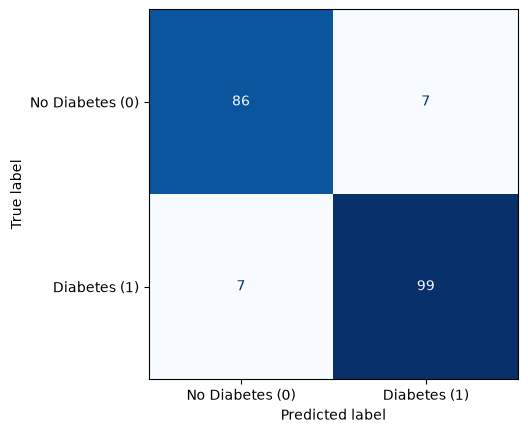

In [49]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes (0)', 'Diabetes (1)'])
disp.plot(cmap='Blues', colorbar=False)
plt.show()

Precision = tn / (tp + fp) => measuring how trustworthy a positive prediction is    
Recall = tp / (tp + fn) => how man =y reak caes we missed   
F1 Score